# Video Game Sales Analysis
## Executive Summary
This project evaluates video game sales patterns across platforms, regions, and genres to identify factors associated with commercial performance.

### Main Findings
- Global sales peak around 2006 to 2011, followed by a sustained decline in annual totals.
- Regional preferences differ meaningfully, especially between North America, Europe, and Japan.
- Platform performance changes over time, so recency is essential for forecasting.
- User and critic signals are useful, but effect size differs by platform and genre.

### Notebook Roadmap
1. Environment setup and reproducible data loading
2. Data cleaning and feature preparation
3. Exploratory analysis and visual diagnostics
4. Statistical hypothesis testing
5. Final conclusions and business implications

In [1]:
# Core imports and project paths
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_PATH = PROJECT_DIR / "data" / "games.csv"
IMAGES_DIR = PROJECT_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(filename: str, fig=None, dpi: int = 300) -> Path:
    """Save the current or provided matplotlib figure to the images directory."""
    fig = fig or plt.gcf()
    output_path = IMAGES_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {output_path}")
    return output_path

print(f"Project directory: {PROJECT_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Images directory: {IMAGES_DIR}")

Project directory: /Users/inezleon/Desktop/DATA_ANALYTICS/TripleTenProjects/video-game-sales-analysis
Data path: /Users/inezleon/Desktop/DATA_ANALYTICS/TripleTenProjects/video-game-sales-analysis/data/games.csv
Images directory: /Users/inezleon/Desktop/DATA_ANALYTICS/TripleTenProjects/video-game-sales-analysis/images


## Step 1: Loading and Initial Data Exploration
This section loads the dataset and validates its structure before transformation.

In [2]:
# Load the dataset from the project data folder
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

data = pd.read_csv(DATA_PATH)
data.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [29]:
# Display basic information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [30]:
# Check for duplicate entries
data.duplicated().sum()

0

### Initial Data Snapshot
- The dataset contains 16,715 records.
- It includes numeric and categorical features relevant to sales modeling.
- Missing values are present in several columns and are addressed in the cleaning section.

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [3]:
# Convert column names to lowercase
data.columns = data.columns.str.lower()
data.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')

### 2.2 Data Type Conversion

In [33]:
# Check current data types
data.dtypes

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

In [ ]:
# Standardize key categorical columns
cols = ['name', 'platform', 'genre']
data[cols] = data[cols].astype('string')

`name`, `platform`, and `genre` are cast to string type to standardize categorical fields and avoid unintended numeric operations.

`user_score` includes `tbd` placeholders. These are converted to nulls and then handled during missing-value processing.

In [ ]:
# Inspect raw user_score values, including 'tbd' placeholders
data['user_score'].value_counts()

tbd    2424
7.8     324
8       290
8.2     282
8.3     254
       ... 
1         2
0.5       2
0.9       2
9.7       1
0         1
Name: user_score, Length: 96, dtype: int64

In [36]:
data.replace(['tbd'], np.nan, inplace=True)

In [37]:
data['user_score'].value_counts()

7.8    324
8      290
8.2    282
8.3    254
8.5    253
      ... 
0.3      2
0.9      2
0.6      2
0        1
9.7      1
Name: user_score, Length: 95, dtype: int64

### 2.3 Handling Missing Values

In [38]:
# Examine missing values
data.isnull().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [39]:
# Calculate percentage of missing values
pct_missing_cols = data.isna().mean().mul(100).round(2)
print(pct_missing_cols.sort_values(ascending=False))

user_score         54.59
critic_score       51.32
rating             40.48
year_of_release     1.61
name                0.01
genre               0.01
platform            0.00
na_sales            0.00
eu_sales            0.00
jp_sales            0.00
other_sales         0.00
dtype: float64


In [40]:
# Analyze patterns in missing values
data[data['genre'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,<NA>,GEN,1993.0,<NA>,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,<NA>,GEN,1993.0,<NA>,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [41]:
data[data['name'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,<NA>,GEN,1993.0,<NA>,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,<NA>,GEN,1993.0,<NA>,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [42]:
data = data.drop(index=[659, 14244])

In [43]:
print(pct_missing_cols.sort_values(ascending=False))

user_score         54.59
critic_score       51.32
rating             40.48
year_of_release     1.61
name                0.01
genre               0.01
platform            0.00
na_sales            0.00
eu_sales            0.00
jp_sales            0.00
other_sales         0.00
dtype: float64


In [44]:
data[data['name'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating


In [45]:
data[data['genre'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating


In [ ]:
# Convert user_score to numeric and impute missing values with the median
data['user_score'] = data['user_score'].replace('tbd', np.nan)
data['user_score'] = pd.to_numeric(data['user_score'], errors='coerce')
userscore_median = data['user_score'].median()
data['user_score'] = data['user_score'].fillna(value=userscore_median)

In [47]:
data['critic_score'] = pd.to_numeric(data['critic_score'], errors='coerce')
criticscore_median = data['critic_score'].median()
data['critic_score'] = data['critic_score'].fillna(value=criticscore_median)

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  string 
 1   platform         16713 non-null  string 
 2   year_of_release  16444 non-null  float64
 3   genre            16713 non-null  string 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     16713 non-null  float64
 9   user_score       16713 non-null  float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(1), string(3)
memory usage: 1.5+ MB


In [49]:
data[data['year_of_release'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,71.0,7.5,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,71.0,7.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,7.5,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,71.0,7.5,NaN


Rows missing both `name` and `genre` were removed because they provide limited analytical value and cannot be reliably recovered.

For `user_score` and `critic_score`, missing values were filled with the median after numeric conversion, which is a robust choice for skewed distributions.

Missing values in `year_of_release` and `rating` were retained to avoid injecting unsupported assumptions into timeline or ESRB-based analyses.

### 2.4 Calculate Total Sales

In [4]:
# Calculate total sales across all regions and put them in a different column
data['total_sales'] = data['eu_sales'] + data['na_sales'] + data['jp_sales']
data['total_sales']

0        74.09
1        39.47
2        32.23
3        29.82
4        30.38
         ...  
16710     0.01
16711     0.01
16712     0.01
16713     0.01
16714     0.01
Name: total_sales, Length: 16715, dtype: float64

# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
This section evaluates release volume by year to identify market expansion, saturation, and decline phases relevant to forecasting.

In [51]:
# Create a DataFrame with game releases by year
releases_by_year = data.groupby('year_of_release').size().reset_index()

releases_by_year.columns = ['year', 'number_of_games']

print(releases_by_year)

      year  number_of_games
0   1980.0                9
1   1981.0               46
2   1982.0               36
3   1983.0               17
4   1984.0               14
5   1985.0               14
6   1986.0               21
7   1987.0               16
8   1988.0               15
9   1989.0               17
10  1990.0               16
11  1991.0               41
12  1992.0               43
13  1993.0               60
14  1994.0              121
15  1995.0              219
16  1996.0              263
17  1997.0              289
18  1998.0              379
19  1999.0              338
20  2000.0              350
21  2001.0              482
22  2002.0              829
23  2003.0              775
24  2004.0              762
25  2005.0              939
26  2006.0             1006
27  2007.0             1197
28  2008.0             1427
29  2009.0             1426
30  2010.0             1255
31  2011.0             1136
32  2012.0              653
33  2013.0              544
34  2014.0          

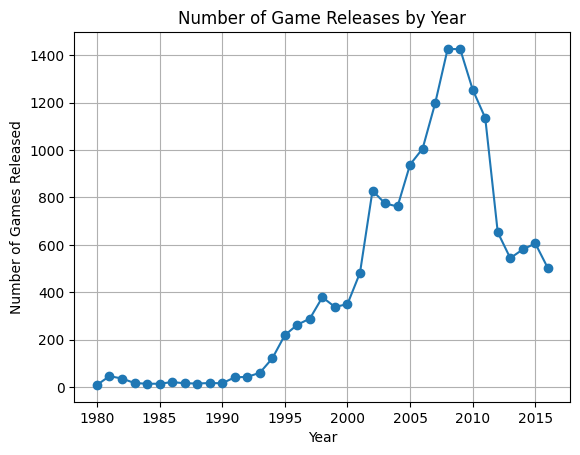

In [52]:
# Visualize the distribution of games across years

plt.plot(releases_by_year['year'], releases_by_year['number_of_games'], marker='o')
plt.title('Number of Game Releases by Year')
plt.xlabel('Year')
plt.ylabel('Number of Games Released')
plt.grid(True)
plt.show()

Release volume peaks in the late 2000s, followed by a clear decline in later years.

In [53]:
# Display summary statistics for each year
yearly_stats = data.groupby('year_of_release').describe()
print(yearly_stats)

                na_sales                                                   \
                   count      mean       std   min     25%    50%     75%   
year_of_release                                                             
1980.0               9.0  1.176667  1.282624  0.22  0.3200  0.720  1.0700   
1981.0              46.0  0.726087  0.730885  0.12  0.2925  0.435  0.8925   
1982.0              36.0  0.747778  1.172248  0.13  0.3150  0.500  0.7225   
1983.0              17.0  0.456471  0.278903  0.01  0.3100  0.430  0.5100   
1984.0              14.0  2.377143  7.089785  0.00  0.0450  0.345  0.7700   
1985.0              14.0  2.409286  7.689309  0.00  0.0000  0.285  0.6025   
1986.0              21.0  0.595238  0.881542  0.00  0.0000  0.320  0.7100   
1987.0              16.0  0.528750  0.653094  0.00  0.1350  0.370  0.4875   
1988.0              15.0  1.591333  2.630154  0.00  0.1000  0.590  1.3700   
1989.0              17.0  2.655882  5.893720  0.00  0.1400  0.660  0.9600   

### Temporal Takeaways
- The highest concentration of releases and sales appears between 2006 and 2011.
- The market contracts after 2011, indicating a structural shift rather than random fluctuation.
- Recent years still contain enough observations to support short-term forecasting for 2017.

## 3.2 Platform Sales Analysis Over Time
This section compares platform sales trajectories across years to identify growth, maturity, and decline patterns.

In [54]:
# Calculate total sales by platform and year


sales_pivot = data.pivot_table(
    values='total_sales', 
    index='platform', 
    columns='year_of_release', 
    aggfunc='sum', 
    fill_value=0
)
sales_pivot


year_of_release,1980.0,1981.0,1982.0,1983.0,1984.0,1985.0,1986.0,1987.0,1988.0,1989.0,...,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0
platform,,,,,,,,,,,,,,,,,,,,,
2600,11.26,35.36,28.57,5.78,0.27,0.45,0.67,1.93,0.73,0.62,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3DO,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3DS,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,58.80,48.77,53.97,41.75,26.75,14.50
DC,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.02,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
DS,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,...,135.85,134.37,110.99,79.48,24.30,10.42,1.42,0.00,0.00,0.00
GB,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.40,63.57,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
GBA,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,3.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
GC,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
GEN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


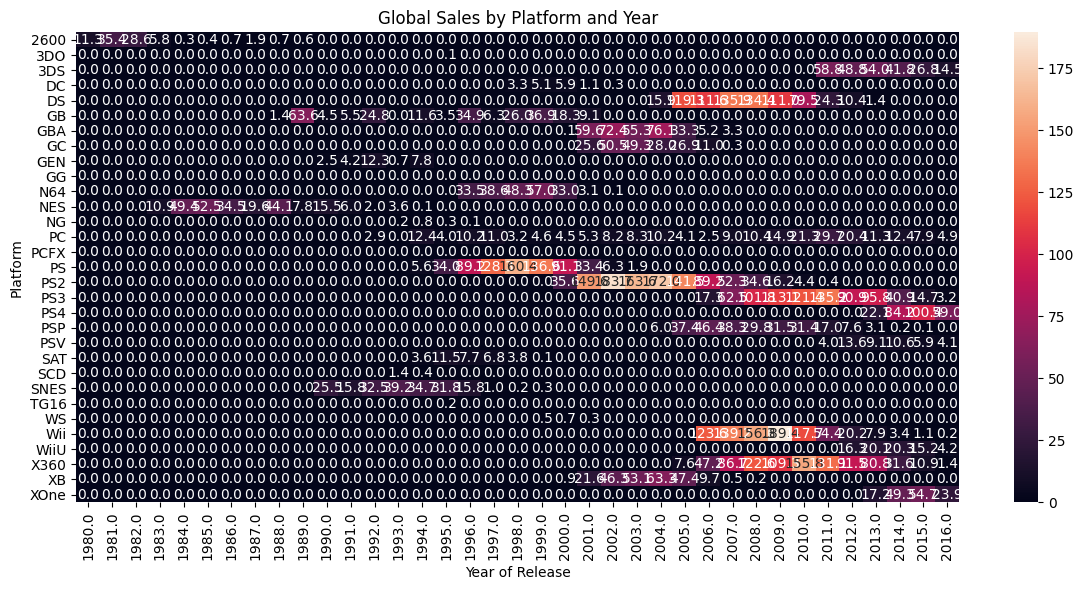

In [55]:
# Create a heatmap of platform sales over time

import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(sales_pivot, annot=True, fmt=".1f")
plt.title('Global Sales by Platform and Year')
plt.ylabel('Platform')
plt.xlabel('Year of Release')
plt.tight_layout()
plt.show()

### Platform Decline Signal
Several legacy platforms show declining sales by 2016, including PS3, Wii, and Xbox 360, consistent with generation turnover.

### Platform Lifecycle Insights
- Platforms with sustained demand usually exhibit multi-year growth followed by decline.
- Older platforms eventually phase out as player demand shifts to newer hardware.
- In this dataset, major platform life cycles generally span about 5 to 6 years around their peak periods.

## 3.3 Determining Relevant Time Period
To estimate 2017 performance, the analysis focuses on the most recent years that best represent current market behavior.

In [ ]:
# Filter to the most recent years used for 2017 forecasting
relevant_years = [2014, 2015, 2016]
predict2017 = data[data['year_of_release'].isin(relevant_years)]

### Time Window Justification
The selected period (2014 to 2016) captures the latest platform landscape and demand patterns before 2017.

Using this recent window reduces bias from outdated platform generations and better reflects current market conditions for short-horizon prediction.

## 3.4 Platform Performance Analysis
Using the selected recent period, this section compares platform-level sales strength and momentum.

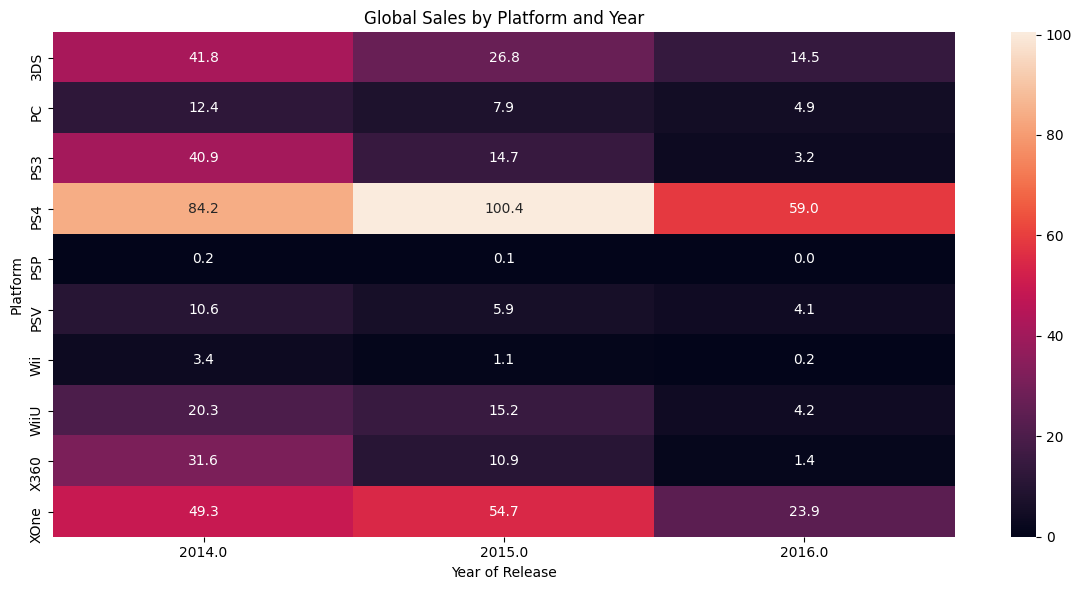

In [57]:
# Analyze platform sales trends

pivot2017 = predict2017.pivot_table(
    values='total_sales', 
    index='platform', 
    columns='year_of_release', 
    aggfunc='sum', 
    fill_value=0
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot2017, annot=True, fmt=".1f")
plt.title('Global Sales by Platform and Year')
plt.ylabel('Platform')
plt.xlabel('Year of Release')
plt.tight_layout()
plt.show()

The heatmap indicates that PS4 is the strongest-performing platform in the most recent years of the dataset.

In [58]:
# Sort platforms by total sales

platform_sales = predict2017.groupby('platform')['total_sales'].sum()
platform_sales.sort_values(ascending=False)


platform
PS4     243.67
XOne    127.84
3DS      83.00
PS3      58.81
X360     43.87
WiiU     39.82
PC       25.20
PSV      20.59
Wii       4.67
PSP       0.36
Name: total_sales, dtype: float64

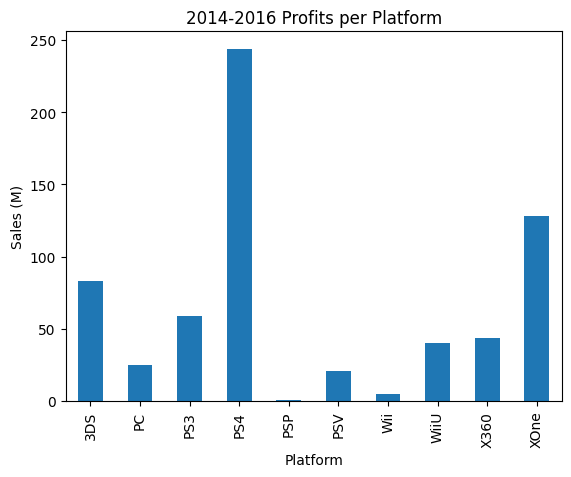

In [ ]:
# Visualize total sales by platform for 2014-2016
platform_sales.plot(kind='bar')
plt.title('2014-2016 Profits per Platform')
plt.xlabel('Platform')
plt.ylabel('Sales (M)')
plt.show()

The PS4 and XBoxOne were the most popular platforms in recent years.

In [ ]:
# Aggregate total sales by platform and year
platform_yearly_sales = predict2017.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

# Compute previous-year sales by platform
platform_yearly_sales['previous_year_sales'] = platform_yearly_sales.groupby('platform')['total_sales'].shift(1)

# Calculate year-over-year growth rate (%)
platform_yearly_sales['yoy_growth'] = (
    (platform_yearly_sales['total_sales'] - platform_yearly_sales['previous_year_sales']) / 
    platform_yearly_sales['previous_year_sales'] * 100
)

platform_yearly_sales

,platform,year_of_release,total_sales,previous_year_sales,yoy_growth
0,3DS,2014.0,41.75,NaN,NaN
1,3DS,2015.0,26.75,41.75,-35.928144
2,3DS,2016.0,14.50,26.75,-45.794393
3,PC,2014.0,12.38,NaN,NaN
4,PC,2015.0,7.93,12.38,-35.945073
5,PC,2016.0,4.89,7.93,-38.335435
6,PS3,2014.0,40.88,NaN,NaN
7,PS3,2015.0,14.70,40.88,-64.041096
8,PS3,2016.0,3.23,14.70,-78.027211
9,PS4,2014.0,84.22,NaN,NaN


Most platform-level growth rates are negative in the selected period, indicating broad revenue contraction across platforms.

## 3.5 Sales Distribution Analysis
This section examines variability and outliers in platform sales distributions.

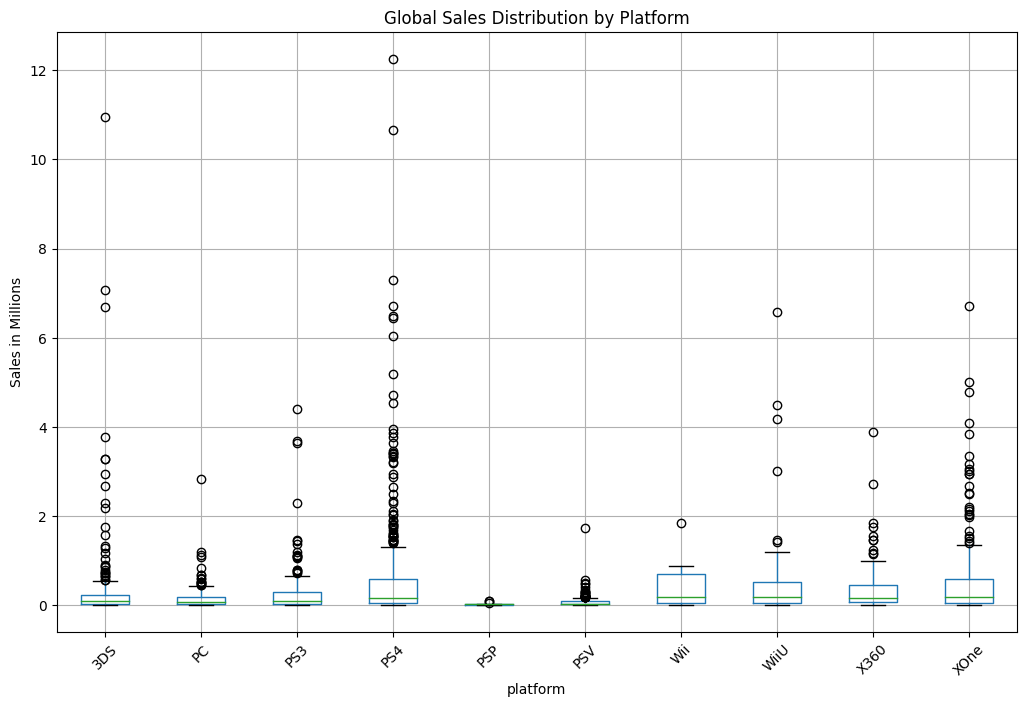

In [61]:
# Create box plot of sales by platform

predict2017.boxplot(column='total_sales', by='platform', figsize=(12, 8))
plt.title('Global Sales Distribution by Platform')
plt.ylabel('Sales in Millions')
plt.suptitle('')  # Remove automatic title
plt.xticks(rotation=45)
plt.show()

In [62]:
# Calculate detailed statistics for each platform

predict2017.groupby('platform')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3DS,212.0,0.391509,1.122935,0.01,0.030,0.080,0.230,10.94
PC,151.0,0.166887,0.304553,0.01,0.020,0.060,0.185,2.82
PS3,219.0,0.268539,0.532896,0.01,0.030,0.090,0.285,4.40
PS4,376.0,0.648059,1.358995,0.01,0.050,0.160,0.580,12.25
PSP,13.0,0.027692,0.027735,0.01,0.010,0.020,0.020,0.09
PSV,295.0,0.069797,0.123748,0.01,0.020,0.030,0.080,1.72
Wii,11.0,0.424545,0.571601,0.01,0.035,0.170,0.695,1.84
WiiU,73.0,0.545479,1.079585,0.01,0.050,0.170,0.520,6.58
X360,111.0,0.395225,0.571941,0.01,0.060,0.160,0.460,3.88


## 3.6 Review Score Impact Analysis
This section evaluates whether critic and user review scores are associated with sales outcomes on a major platform.

In [63]:
# Choose a popular platform based on your previous analysis

ps4 = data[data['platform'] == 'PS4']
ps4

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,71.0,7.5,NaN,12.25
42,Grand Theft Auto V,PS4,2014.0,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,10.65
77,FIFA 16,PS4,2015.0,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,7.30
87,Star Wars Battlefront (2015),PS4,2015.0,Shooter,2.99,3.49,0.22,1.28,71.0,7.5,NaN,6.70
92,Call of Duty: Advanced Warfare,PS4,2014.0,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,6.43
...,...,...,...,...,...,...,...,...,...,...,...,...
16500,Root Letter,PS4,2016.0,Adventure,0.00,0.00,0.01,0.00,69.0,7.5,NaN,0.01
16503,Shin Hayarigami 2,PS4,2016.0,Adventure,0.00,0.00,0.01,0.00,71.0,7.5,NaN,0.01
16526,Dungeons 2,PS4,2016.0,Role-Playing,0.01,0.00,0.00,0.00,61.0,7.9,T,0.01
16530,Carmageddon: Max Damage,PS4,2016.0,Action,0.01,0.00,0.00,0.00,51.0,5.5,M,0.01


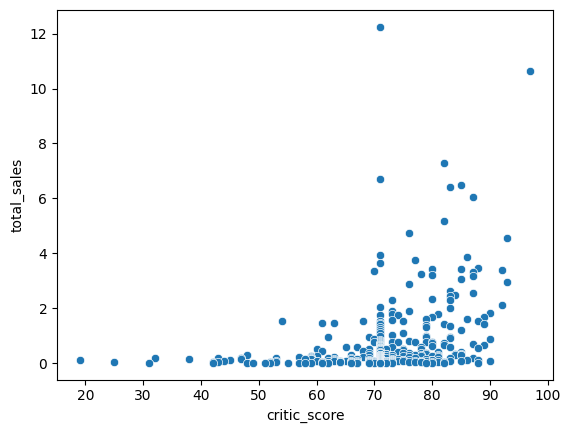

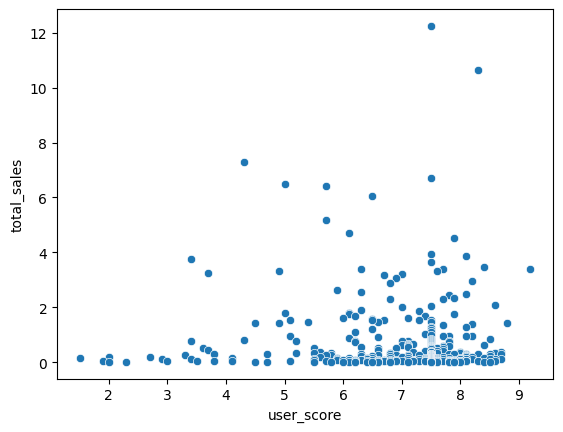

In [64]:
# Create scatter plots for both critic and user scores

sns.scatterplot(data=ps4, x='critic_score', y='total_sales')
plt.show()
sns.scatterplot(data=ps4, x='user_score', y='total_sales')
plt.show()

`total_sales` is treated as the response variable to measure how strongly review metrics relate to commercial performance.

In [65]:
# Calculate correlations

# Remove any rows with missing values for accurate correlation
clean_data = ps4.dropna(subset=['critic_score', 'user_score', 'total_sales'])

# Calculate correlation coefficients
critic_correlation = clean_data['critic_score'].corr(clean_data['total_sales'])
user_correlation = clean_data['user_score'].corr(clean_data['total_sales'])

print(f"Correlation between Critic Score and Sales: {critic_correlation:.3f}")
print(f"Correlation between User Score and Sales: {user_correlation:.3f}")

Correlation between Critic Score and Sales: 0.339
Correlation between User Score and Sales: -0.062


## 3.7 Cross-Platform Comparison
This section compares aggregate performance for games released across multiple platforms.

In [66]:
# Find games released on multiple platforms

# Count how many platforms each game appears on
games_per_platform = data.groupby('name').agg({
    'platform': 'count',
    'total_sales': 'sum'
}).rename(columns={'platform': 'platform_count'})

# Filter for games that appear on multiple platforms (2 or more)
multi_platform_games = games_per_platform[games_per_platform['platform_count'] >= 2]

print(f"Number of games released on multiple platforms: {len(multi_platform_games)}")
print(f"Games with most platform releases:")
print(multi_platform_games.sort_values('platform_count', ascending=False).head(10))


Number of games released on multiple platforms: 2805
Games with most platform releases:
                              platform_count  total_sales
name                                                     
Need for Speed: Most Wanted               12        12.08
Madden NFL 07                              9         9.13
LEGO Marvel Super Heroes                   9         8.30
FIFA 14                                    9        13.97
Ratatouille                                9         3.38
Terraria                                   8         1.43
Angry Birds Star Wars                      8         1.52
LEGO Jurassic World                        8         4.13
Lego Batman 3: Beyond Gotham               8         3.72
FIFA Soccer 13                             8        13.02


In [ ]:
# Identify platforms represented by multi-platform titles
top_games = multi_platform_games.index
top_platforms = data[data['name'].isin(top_games)]['platform'].unique()
top_platforms

<StringArray>
[ 'NES',   'GB',  'PS3',  'PS2', 'SNES', 'X360',  'PS4',  'N64',   'DS',
  'Wii',   'XB',   'PC', '2600',  'PSP',  '3DS', 'XOne',   'PS',  'GBA',
 'WiiU',   'GC',  'GEN',  'PSV',   'DC',  'SAT',   'WS',   'NG']
Length: 26, dtype: string

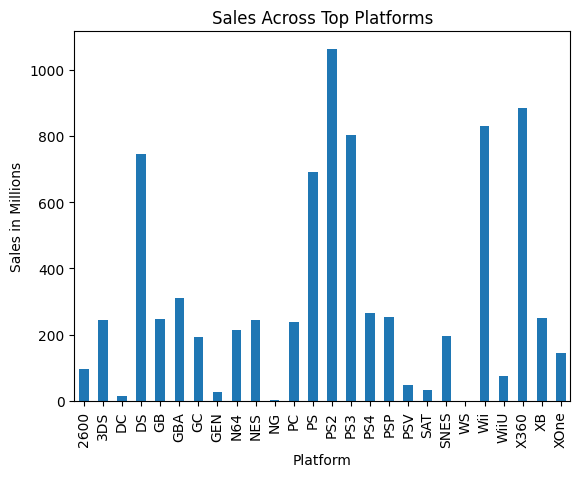

In [68]:

filtered_data = data[data['platform'].isin(top_platforms)]

# group by platform
platform_sales = filtered_data.groupby('platform')['total_sales'].sum()

platform_sales.plot(kind='bar')
plt.title('Sales Across Top Platforms')
plt.ylabel('Sales in Millions')
plt.xlabel('Platform')
plt.show()

The chart summarizes sales distribution across platforms represented by top multi-platform titles.

## 3.8 Genre Analysis
This section evaluates genre-level sales concentration and trend behavior over time.

In [69]:
# Sort genres by total sales
genre_sales = data.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales

genre
Action          1559.57
Sports          1196.76
Shooter          948.34
Role-Playing     874.93
Platform         776.68
Misc             728.12
Racing           652.57
Fighting         411.17
Simulation       359.24
Puzzle           230.19
Adventure        221.10
Strategy         163.38
Name: total_sales, dtype: float64

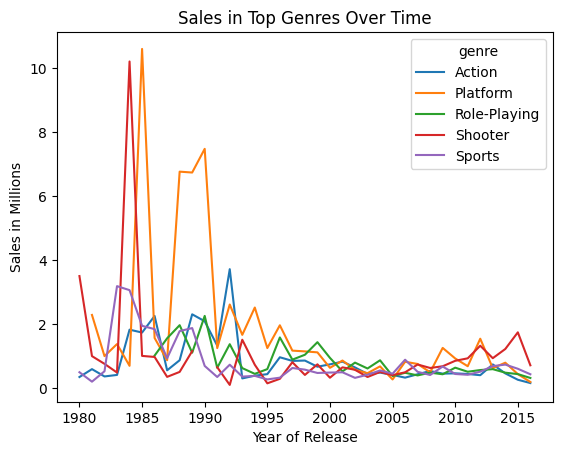

In [70]:
top_genres_list = {'Action', 'Sports', 'Shooter', 'Role-Playing', 'Platform'}
top_genres = filtered_data[filtered_data['genre'].isin(top_genres_list)]

genre_performance2 = top_genres.pivot_table(index='year_of_release', columns='genre', values='total_sales')
genre_performance2.plot(kind='line')
plt.title('Sales in Top Genres Over Time')
plt.ylabel('Sales in Millions')
plt.xlabel('Year of Release')
plt.show()

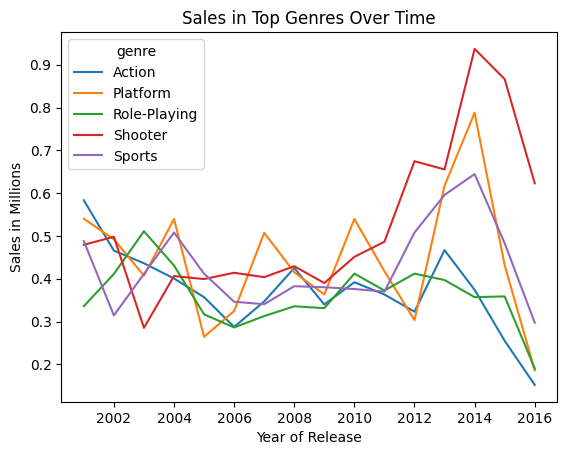

In [71]:
top_genres_list = {'Action', 'Sports', 'Shooter', 'Role-Playing', 'Platform'}
top_genres = filtered_data[filtered_data['genre'].isin(top_genres_list)]

top_genres_recent = top_genres[top_genres['year_of_release'] > 2000]
top_genres_recent = top_genres_recent[top_genres_recent['total_sales'] < 4]

genre_performance2 = top_genres_recent.pivot_table(index='year_of_release', columns='genre', values='total_sales')
genre_performance2.plot(kind='line')
plt.title('Sales in Top Genres Over Time')
plt.ylabel('Sales in Millions')
plt.xlabel('Year of Release')
plt.show()

The zoomed trend view highlights relative genre movement in recent years where total sales levels are lower.

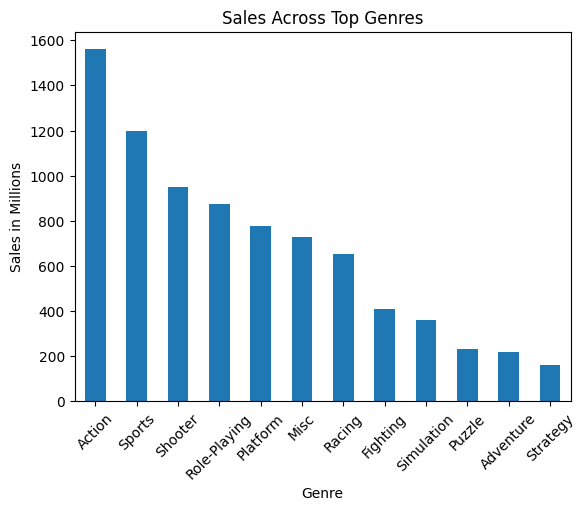

In [72]:
# Visualize genre distribution
genre_sales.plot(kind='bar')
plt.title('Sales Across Top Genres')
plt.ylabel('Sales in Millions')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.show()

In [73]:
# Calculate market share for each genre

genre_sales = data.groupby('genre')['total_sales'].sum()

total_market_sales = data['total_sales'].sum()
market_share = (genre_sales / total_market_sales) * 100

market_share_sorted = market_share.sort_values(ascending=False)

print("Market Share by Genre (%):")
print(market_share_sorted)

Market Share by Genre (%):
genre
Action          19.201679
Sports          14.734704
Shooter         11.676116
Role-Playing    10.772280
Platform         9.562610
Misc             8.964732
Racing           8.034548
Fighting         5.062392
Simulation       4.423021
Puzzle           2.834137
Adventure        2.722219
Strategy         2.011561
Name: total_sales, dtype: float64


### Genre Takeaways
- `Action` contributes the highest cumulative sales in the full dataset.
- In recent years, `Shooter` and `Platform` genres show comparatively stronger positioning.
- Most genres trend downward over time, but decline rates vary by genre.

# Step 4: Regional Market Analysis and User Profiles
This section compares market behavior across North America (NA), Europe (EU), and Japan (JP), focusing on platform strength, genre mix, and ESRB rating effects.

## 4.1 Regional Platform Analysis
The following analysis profiles platform performance across regions.

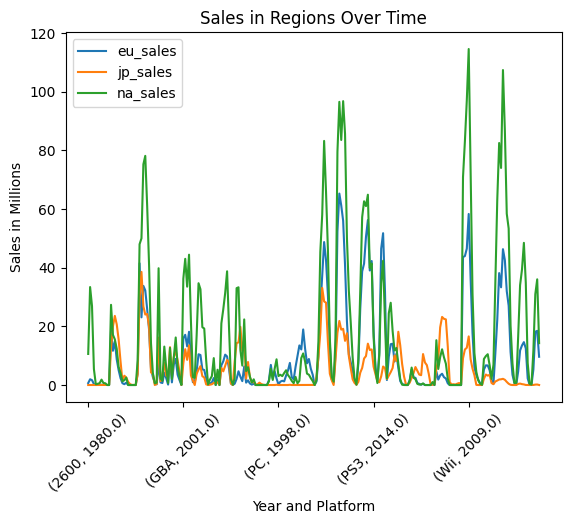

In [ ]:
# Aggregate regional sales by platform and year
region = data.groupby(['platform', 'year_of_release'])['eu_sales', 'jp_sales', 'na_sales'].sum()
region.plot(kind='line')
plt.title('Sales in Regions Over Time')
plt.ylabel('Sales in Millions')
plt.xlabel('Year and Platform')
plt.xticks(rotation=45)
plt.show()

The outputs below summarize each region’s highest-performing platform-year combinations.

In [75]:
# Analyze each region
eu = data.groupby(['platform', 'year_of_release'])['eu_sales'].sum()
eu.sort_values(ascending=False)

platform  year_of_release
PS2       2002.0             65.27
          2003.0             61.20
Wii       2009.0             58.31
PS3       2011.0             56.24
PS2       2004.0             56.01
                             ...  
NG        1994.0              0.00
          1993.0              0.00
NES       1994.0              0.00
PSP       2014.0              0.00
PCFX      1996.0              0.00
Name: eu_sales, Length: 238, dtype: float64

In [76]:
na = data.groupby(['platform', 'year_of_release'])['na_sales'].sum()
na.sort_values(ascending=False)

platform  year_of_release
Wii       2009.0             114.55
X360      2010.0             107.38
Wii       2008.0              97.12
PS2       2004.0              96.78
          2002.0              96.54
                              ...  
TG16      1995.0               0.00
WS        1999.0               0.00
          2000.0               0.00
          2001.0               0.00
PCFX      1996.0               0.00
Name: na_sales, Length: 238, dtype: float64

In [77]:
jp = data.groupby(['platform', 'year_of_release'])['jp_sales'].sum()
jp.sort_values(ascending=False)

platform  year_of_release
DS        2006.0             38.56
PS        1997.0             33.10
DS        2005.0             29.86
PS        1998.0             28.48
          1999.0             28.07
                             ...  
PC        2001.0              0.00
          2000.0              0.00
          1999.0              0.00
          1998.0              0.00
2600      1980.0              0.00
Name: jp_sales, Length: 238, dtype: float64

### Cross-Regional Platform Comparison
This comparison highlights how platform demand differs across NA, EU, and JP.

In [78]:
# Create a comparative platform analysis

region_platform = data.groupby('platform')['eu_sales', 'jp_sales', 'na_sales'].sum()
region_platform.sort_values(by=['eu_sales', 'jp_sales', 'na_sales'], ascending=False)


,eu_sales,jp_sales,na_sales
platform,,,
PS2,339.29,139.20,583.84
PS3,330.29,80.19,393.49
X360,270.76,12.43,602.47
Wii,262.21,69.33,496.90
PS,213.61,139.82,336.52
DS,188.89,175.57,382.40
PC,142.44,0.17,94.53
PS4,141.09,15.96,108.74
GBA,75.25,47.33,187.54


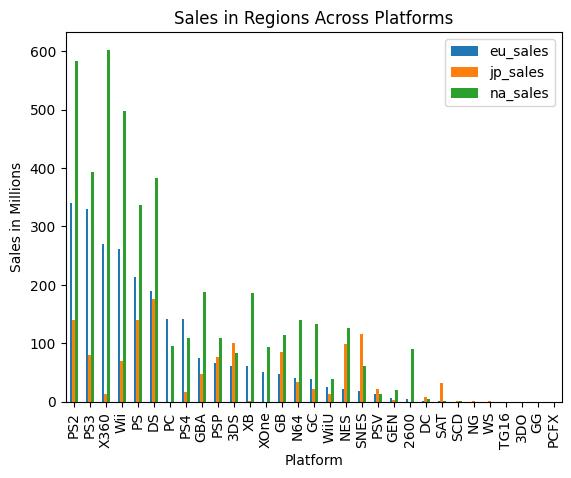

In [79]:
# Visualize cross-regional comparison for top platforms
region_platform = region_platform.sort_values(by=['eu_sales', 'jp_sales', 'na_sales'], ascending=False)
region_platform.plot(kind='bar')
plt.title('Sales in Regions Across Platforms')
plt.ylabel('Sales in Millions')
plt.xlabel('Platform')
plt.show()

The comparative chart indicates that X360 leads in North America, PS2 leads in Europe, and DS leads in Japan.

## 4.2 Regional Genre Analysis
This section evaluates genre preferences by region to identify demand asymmetries.

In [ ]:
# Aggregate regional sales by genre
region_genre = data.groupby('genre')['eu_sales', 'jp_sales', 'na_sales'].sum()
region_genre.sort_values(by=['eu_sales', 'jp_sales', 'na_sales'], ascending=False)

,eu_sales,jp_sales,na_sales
genre,,,
Action,519.13,161.43,879.01
Sports,376.79,135.54,684.43
Shooter,317.34,38.76,592.24
Racing,236.51,56.71,359.35
Misc,212.74,108.11,407.27
Platform,200.35,130.83,445.50
Role-Playing,188.71,355.41,330.81
Simulation,113.52,63.80,181.92
Fighting,100.33,87.48,223.36


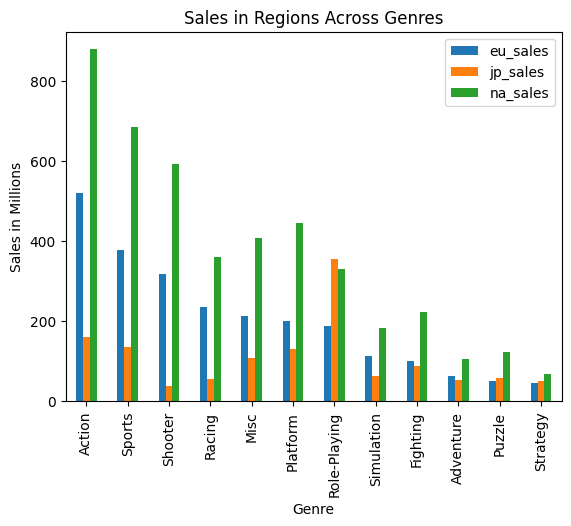

In [81]:
region_genre = region_genre.sort_values(by=['eu_sales', 'jp_sales', 'na_sales'], ascending=False)
region_genre.plot(kind='bar')
plt.title('Sales in Regions Across Genres')
plt.ylabel('Sales in Millions')
plt.xlabel('Genre')
plt.show()

Results indicate `Action` is the top genre in North America and Europe, while `Role-Playing` leads in Japan.

## 4.3 ESRB Rating Impact Analysis
This section measures how ESRB rating categories map to regional sales outcomes.

In [ ]:
# Aggregate regional sales by ESRB rating
data.groupby('rating')['eu_sales', 'jp_sales', 'na_sales'].sum().sort_values(by=['eu_sales', 'jp_sales', 'na_sales'], ascending=False)

,eu_sales,jp_sales,na_sales
rating,,,
E,710.25,198.11,1292.99
M,483.97,64.24,748.48
T,427.03,151.40,759.75
E10+,188.52,40.20,353.32
AO,0.61,0.00,1.26
K-A,0.27,1.46,2.56
EC,0.11,0.00,1.53
RP,0.08,0.00,0.00


The following plots show sales distribution by ESRB rating for each region.

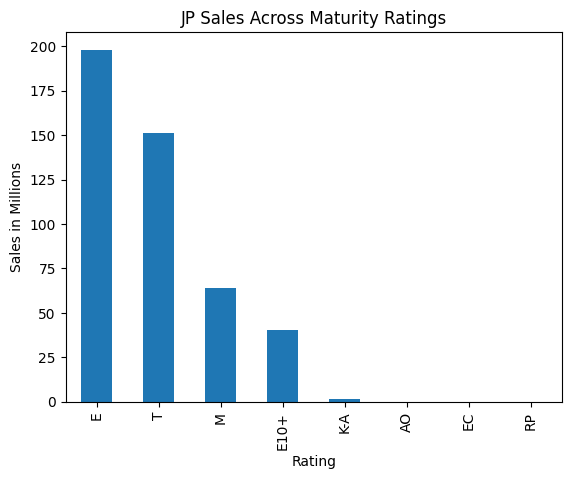

In [84]:
# Analyze ESRB impact for each region


jp_rating = data.groupby('rating')['jp_sales'].sum()
jp_rating = jp_rating.sort_values(ascending=False)
jp_rating.plot(kind='bar')
plt.title('JP Sales Across Maturity Ratings')
plt.ylabel('Sales in Millions')
plt.xlabel('Rating')
plt.show()


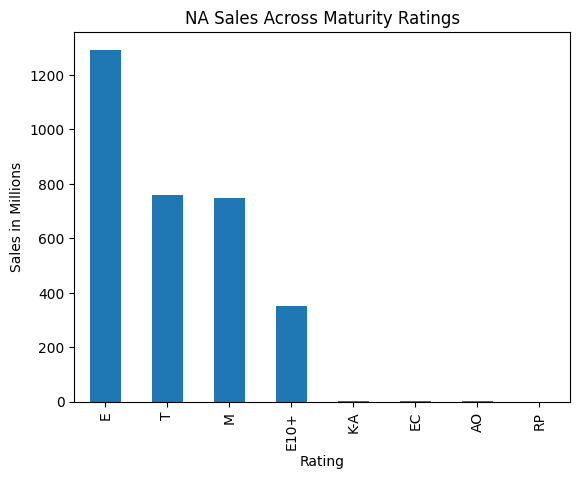

In [85]:
na_rating = data.groupby('rating')['na_sales'].sum()
na_rating = na_rating.sort_values(ascending=False)
na_rating.plot(kind='bar')
plt.title('NA Sales Across Maturity Ratings')
plt.ylabel('Sales in Millions')
plt.xlabel('Rating')
plt.show()

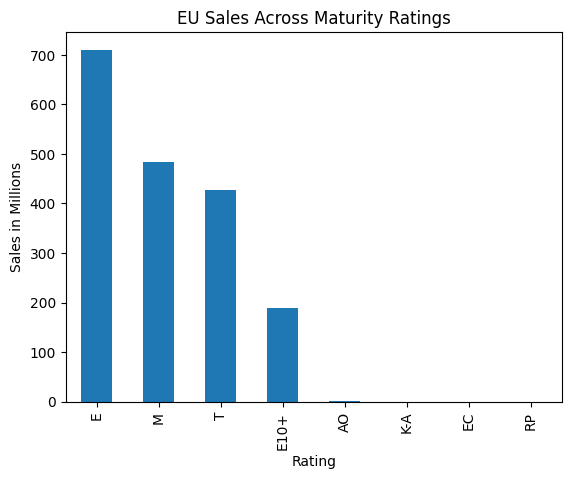

In [86]:
eu_rating = data.groupby('rating')['eu_sales'].sum()
eu_rating = eu_rating.sort_values(ascending=False)
eu_rating.plot(kind='bar')
plt.title('EU Sales Across Maturity Ratings')
plt.ylabel('Sales in Millions')
plt.xlabel('Rating')
plt.show()

# Step 5: Hypothesis Tests
Two statistical tests are used to evaluate whether average user ratings differ across selected platform and genre pairs.

**Test A**
- Null hypothesis ($H_0$): Mean user ratings for Xbox One and PC are equal.
- Alternative hypothesis ($H_1$): Mean user ratings for Xbox One and PC are different.

In [87]:
data['platform'].value_counts()

PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
PCFX       1
GG         1
Name: platform, dtype: Int64

In [ ]:
from scipy import stats as st

# Prepare user scores for the platform-level hypothesis test
data['user_score'] = pd.to_numeric(data['user_score'], errors='coerce')

# Subset Xbox One and PC observations
xbox = data[data['platform'] == 'XOne']
pc = data[data['platform'] == 'PC']

# Drop missing values before t-test
xbox_scores = xbox['user_score'].dropna()
pc_scores = pc['user_score'].dropna()

alpha = .05

results = st.ttest_ind(xbox_scores, pc_scores)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value: 0.00010123955107193582
We reject the null hypothesis


**Test B**
- Null hypothesis ($H_0$): Mean user ratings for Action and Sports games are equal.
- Alternative hypothesis ($H_1$): Mean user ratings for Action and Sports games are different.

In [ ]:
# Subset Action and Sports observations for genre-level hypothesis test
action = data[data['genre'] == 'Action']
sports = data[data['genre'] == 'Sports']

# Drop missing values before t-test
action_scores = action['user_score'].dropna()
sports_scores = sports['user_score'].dropna()

alpha = .05

results = st.ttest_ind(action_scores, sports_scores)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value: 0.7131417795320426
We can't reject the null hypothesis


## Export Visualizations to images/
The following cells save final report-ready figures to the project images directory.

Saved: /Users/inezleon/Desktop/DATA_ANALYTICS/TripleTenProjects/video-game-sales-analysis/images/releases_by_year.png


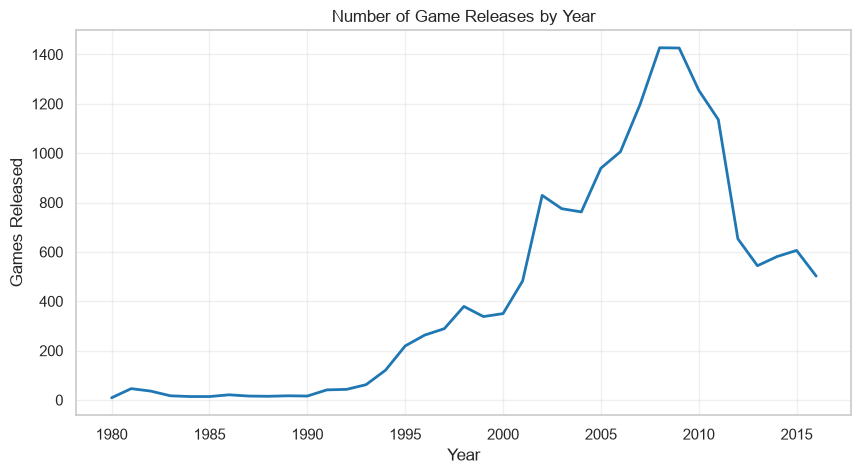

Saved: /Users/inezleon/Desktop/DATA_ANALYTICS/TripleTenProjects/video-game-sales-analysis/images/top_platform_total_sales.png


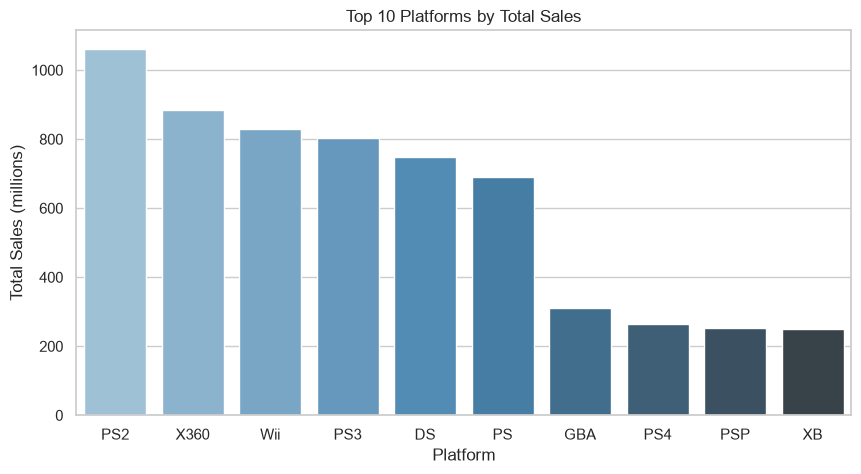

Saved: /Users/inezleon/Desktop/DATA_ANALYTICS/TripleTenProjects/video-game-sales-analysis/images/regional_sales_totals.png


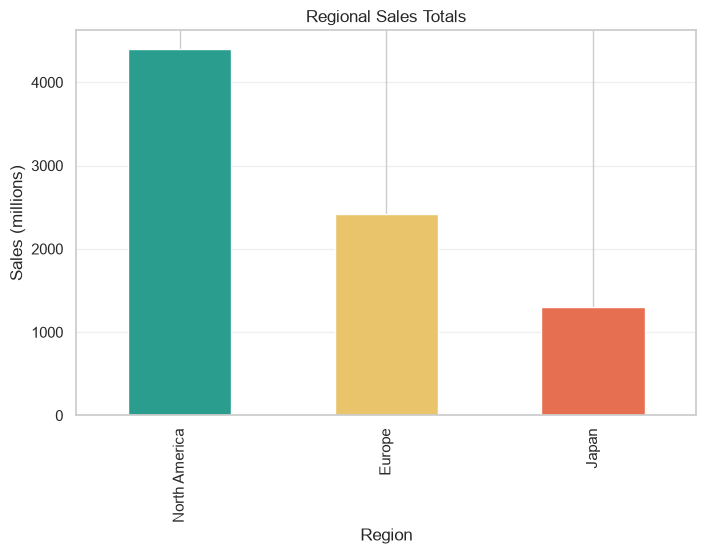

In [5]:
# 1) Annual release trend
release_counts = (
    data.dropna(subset=["year_of_release"])
    .groupby("year_of_release")
    .size()
    .sort_index()
    .rename("games_released")
)

fig, ax = plt.subplots(figsize=(10, 5))
release_counts.plot(ax=ax, color="#1f77b4", linewidth=2)
ax.set_title("Number of Game Releases by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Games Released")
ax.grid(alpha=0.3)
save_figure("releases_by_year.png", fig)
plt.show()

# 2) Top platforms by total sales
top_platform_sales = (
    data.groupby("platform", as_index=False)["total_sales"]
    .sum()
    .sort_values("total_sales", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_platform_sales, x="platform", y="total_sales", ax=ax, palette="Blues_d")
ax.set_title("Top 10 Platforms by Total Sales")
ax.set_xlabel("Platform")
ax.set_ylabel("Total Sales (millions)")
save_figure("top_platform_total_sales.png", fig)
plt.show()

# 3) Regional sales profile
regional_totals = data[["na_sales", "eu_sales", "jp_sales"]].sum().rename(
    {"na_sales": "North America", "eu_sales": "Europe", "jp_sales": "Japan"}
 )

fig, ax = plt.subplots(figsize=(8, 5))
regional_totals.plot(kind="bar", ax=ax, color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_title("Regional Sales Totals")
ax.set_xlabel("Region")
ax.set_ylabel("Sales (millions)")
ax.grid(axis="y", alpha=0.3)
save_figure("regional_sales_totals.png", fig)
plt.show()

# Step 6. Conclusion

This analysis shows that video game sales dynamics are time-sensitive and region-specific. Global sales reached their highest levels during roughly 2006 to 2011, then declined, which supports focusing on modern data for forecasting decisions.

North America and Europe account for most sales volume, but Japan has distinct genre and platform preferences, so a one-size-fits-all release strategy is suboptimal. Platform life cycles also matter: high-performing platforms rotate over time, and recent years provide the strongest signal for short-term planning.

Hypothesis tests suggest that user-score behavior differs by segment rather than remaining uniform across all platform and genre groups. Combined with exploratory findings, this supports a targeted market strategy by region, platform, and genre when planning game launches.